In [162]:
# Libraries for data preparation & visualization
import numpy as np
import polars as pl
import pandas as pd

# Ignore printing warnings for general readability
# import warnings 
# warnings.filterwarnings("ignore")

# pip install scikit-surprise
# Importing libraries for model building & evaluation
from surprise import Reader, Dataset
from surprise.model_selection import train_test_split, cross_validate, GridSearchCV
from surprise import KNNBasic, KNNWithMeans, KNNWithZScore, KNNBaseline
from surprise import accuracy
import random

In [163]:
# Use your path in local
book   = pl.read_csv("./datalake/clean_merge/books.csv", schema={
    'isbn13': pl.String,
    'title': pl.String,
    'crawl_source': pl.String,
    'isbn10': pl.String,
    'description': pl.String,
    'image_url': pl.String,
    'author': pl.String,
    'language': pl.String,
    'publish_date': pl.String,
    'num_pages': pl.Int64
}, new_columns=[
    'isbn13','title','crawl_source','isbn10'
])

user   = pl.read_csv("./datalake/clean_merge/users.csv", new_columns=['full_name','account_source','userid_source_original','userid'])
rating = pl.read_csv("./datalake/clean_merge/ratings.csv", schema_overrides={
    'isbn13': pl.String,
}, new_columns=[
    'rating_score','userid','isbn13','account_source'
])

print("Book:", book)
print("User:", user)
print("Rating:", rating)

Book: shape: (284_923, 10)
┌───────────────┬────────────────┬──────────────┬────────────┬───┬───────────────┬──────────┬──────────────┬───────────┐
│ isbn13        ┆ title          ┆ crawl_source ┆ isbn10     ┆ … ┆ author        ┆ language ┆ publish_date ┆ num_pages │
│ ---           ┆ ---            ┆ ---          ┆ ---        ┆   ┆ ---           ┆ ---      ┆ ---          ┆ ---       │
│ str           ┆ str            ┆ str          ┆ str        ┆   ┆ str           ┆ str      ┆ str          ┆ i64       │
╞═══════════════╪════════════════╪══════════════╪════════════╪═══╪═══════════════╪══════════╪══════════════╪═══════════╡
│ 9780578406053 ┆ The Beauty Of  ┆ hardcover    ┆ 0578406055 ┆ … ┆ Charles S.    ┆ English  ┆ 2018-11-12   ┆ 0         │
│               ┆ The Mass:      ┆              ┆            ┆   ┆ Johnston      ┆          ┆              ┆           │
│               ┆ Explor…        ┆              ┆            ┆   ┆               ┆          ┆              ┆           │
│ 978

In [164]:
rating_users = rating['isbn13'].value_counts()
rating_books = rating['userid'].value_counts()
print(rating_users)
print(rating_books)

shape: (215_916, 2)
┌───────────────┬───────┐
│ isbn13        ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ 9781510751262 ┆ 1     │
│ 9780785168263 ┆ 1     │
│ 9780802715517 ┆ 3     │
│ 9786185116897 ┆ 1     │
│ 9780199535583 ┆ 1     │
│ …             ┆ …     │
│ 9781419719714 ┆ 2     │
│ 9780140449181 ┆ 3     │
│ 9780380717156 ┆ 1     │
│ 9781848563216 ┆ 1     │
│ 9780374445980 ┆ 1     │
└───────────────┴───────┘
shape: (29_149, 2)
┌────────┬───────┐
│ userid ┆ count │
│ ---    ┆ ---   │
│ i64    ┆ u32   │
╞════════╪═══════╡
│ 19278  ┆ 172   │
│ 30210  ┆ 8     │
│ 30051  ┆ 363   │
│ 39164  ┆ 65    │
│ 16199  ┆ 2     │
│ …      ┆ …     │
│ 6671   ┆ 1     │
│ 1524   ┆ 2     │
│ 19138  ┆ 1     │
│ 5875   ┆ 5     │
│ 3636   ┆ 58    │
└────────┴───────┘


In [165]:
# In order to avoid rating bias & for making good recommendations, limit the dataset to only those
# users that have made at least 100 ratings & books that have received at least 50 ratings

rating_test = rating.join(
    rating_users, on="isbn13", how="left"
).rename({'count':'user_rated_count'}).join(
    rating_books, on='userid', how="left"
).rename({'count':'book_rated_count'})

rating_test = rating_test.filter((pl.col("user_rated_count") >= 100) & (pl.col("book_rated_count") >= 50))
rating_test

rating_score,userid,isbn13,account_source,user_rated_count,book_rated_count
f64,i64,str,str,u32,u32
3.0,32793,"""9781905294770""","""hardcover""",218,297
5.0,25493,"""9780399590504""","""hardcover""",602,83
5.0,37000,"""9780142437247""","""hardcover""",319,571
5.0,23850,"""9780765316899""","""hardcover""",978,284
4.0,26284,"""9781250859143""","""hardcover""",240,328
…,…,…,…,…,…
5.0,28389,"""9780316362467""","""hardcover""",273,859
4.0,3396,"""9781594631764""","""goodreads""",154,1567
5.0,33004,"""9780297853350""","""hardcover""",268,365


In [166]:
rating_test.describe()

statistic,rating_score,userid,isbn13,account_source,user_rated_count,book_rated_count
str,f64,f64,str,str,f64,f64
"""count""",477758.0,477758.0,"""477758""","""477758""",477758.0,477758.0
"""null_count""",0.0,0.0,"""0""","""0""",0.0,0.0
"""mean""",3.994687,28975.096792,null,null,516.913492,325.638332
"""std""",0.942764,7227.267687,null,null,527.200071,323.693675
"""min""",0.0,62.0,"""807897015021""","""goodreads""",100.0,50.0
"""25%""",3.0,25545.0,null,null,172.0,130.0
"""50%""",4.0,29801.0,null,null,315.0,233.0
"""75%""",5.0,33705.0,null,null,630.0,409.0
"""max""",5.0,40145.0,"""9870575084162""","""hardcover""",2941.0,10502.0


In [167]:
# For the recommendation system, it is prefered to have the book titles rather than isbn13 for easier interpretation

rating_all = rating_test.join(book, on="isbn13",how="left").select(['userid','isbn13','rating_score','title']) # merging with the book dataframe
rating_all             

userid,isbn13,rating_score,title
i64,str,f64,str
32793,"""9781905294770""",3.0,"""Inkheart"""
25493,"""9780399590504""",5.0,"""Educated: A Memoir"""
37000,"""9780142437247""",5.0,"""Moby-Dick or, the Whale"""
23850,"""9780765316899""",5.0,"""The Hero of Ages"""
26284,"""9781250859143""",4.0,"""Mistborn: Secret History"""
…,…,…,…
28389,"""9780316362467""",5.0,"""Kings of the Wyld"""
3396,"""9781594631764""",4.0,"""And the Mountains Echoed"""
33004,"""9780297853350""",5.0,"""The Color Purple"""


In [168]:
print("Book count:", rating_all.select('isbn13').unique().shape[0])
print("User count:", rating_all.select('userid').unique().shape[0])

Book count: 2017
User count: 5840


In [169]:
ratings_explicit = rating_all.filter(pl.col("rating_score") != 0)
ratings_implicit = rating_all.filter(pl.col("rating_score") == 0)
print(ratings_explicit.shape)
print(ratings_implicit.shape)

(477740, 4)
(18, 4)


In [170]:
# creating a surprise object

reader = Reader(rating_scale=(1, 10))
data_nonzero   = Dataset.load_from_df(ratings_explicit.select(['userid','isbn13','rating_score']).to_pandas(), reader)
# data  = Dataset.load_from_df(rating[['userid','isbn13','rating_score']], reader)

# Split the data into training & testing sets. 

raw_ratings_nonzero = data_nonzero.raw_ratings
random.shuffle(raw_ratings_nonzero)                 # shuffle dataset

threshold   = int(len(raw_ratings_nonzero)*0.8)

train_raw_ratings = raw_ratings_nonzero[:threshold] # 80% of data is trainset
test_raw_ratings  = raw_ratings_nonzero[threshold:] # 20% of data is testset

data_nonzero.raw_ratings = train_raw_ratings        # data is now the trainset
trainset         = data_nonzero.build_full_trainset() 
testset          = data_nonzero.construct_testset(test_raw_ratings)


In [171]:
# Trying KNN (K-Nearest Neighbors) with explicit rating data

models=[KNNBasic(),KNNWithMeans(),KNNWithZScore(),KNNBaseline()] 
results = {}

for model in models:
    # perform 5 fold cross validation
    # evaluation metrics: mean absolute error & root mean square error
    CV_scores = cross_validate(model, data_nonzero, measures=["MAE","RMSE"], cv=5, n_jobs=-1)  
    
    # storing the average score across the 5 fold cross validation for each model
    result = pd.DataFrame.from_dict(CV_scores).mean(axis=0).\
             rename({'test_mae':'MAE', 'test_rmse': 'RMSE'})
    results[str(model).split("algorithms.")[1].split("object ")[0]] = result

In [172]:
performance_df = pd.DataFrame.from_dict(results)
print("Model Performance: \n")
performance_df.T.sort_values(by='RMSE')

Model Performance: 



,MAE,RMSE,fit_time,test_time
knns.KNNBaseline,0.647435,0.829074,10.051688,23.875620
knns.KNNWithMeans,0.653957,0.835755,9.387515,17.427873
knns.KNNWithZScore,0.652280,0.835836,9.423832,18.699000
knns.KNNBasic,0.673158,0.865348,9.875237,17.172032


### Hyperparameter tuning

In [173]:
# Hyperparameter tuning - KNNBasic with data_nonzero

param_grid = { 'sim_options' : {'name': ['msd','cosine','pearson','pearson_baseline'], \
                                'min_support': [1,5], \
                                'user_based': [False, True]}
             }

gridsearchKNNBasic = GridSearchCV(KNNBasic, param_grid, measures=['mae', 'rmse'], cv=5, n_jobs=-1)
                                    
gridsearchKNNBasic.fit(data_nonzero)

print(f'MAE Best Parameters:  {gridsearchKNNBasic.best_params["mae"]}')
print(f'MAE Best Score:       {gridsearchKNNBasic.best_score["mae"]}\n')

print(f'RMSE Best Parameters: {gridsearchKNNBasic.best_params["rmse"]}')
print(f'RMSE Best Score:      {gridsearchKNNBasic.best_score["rmse"]}\n')

MAE Best Parameters:  {'sim_options': {'name': 'pearson_baseline', 'min_support': 1, 'user_based': False}}
MAE Best Score:       0.659680404427513

RMSE Best Parameters: {'sim_options': {'name': 'pearson_baseline', 'min_support': 1, 'user_based': False}}
RMSE Best Score:      0.8504070421608763



In [174]:
# Hyperparameter tuning - KNNWithMeans with data_nonzero

param_grid = { 'sim_options' : {'name': ['msd','cosine','pearson','pearson_baseline'], \
                                'min_support': [1,5], \
                                'user_based': [False, True]}
             }

gridsearchKNNWithMeans = GridSearchCV(KNNWithMeans, param_grid, measures=['mae', 'rmse'], cv=5, n_jobs=-1)
                                    
gridsearchKNNWithMeans.fit(data_nonzero)

print(f'MAE Best Parameters:  {gridsearchKNNWithMeans.best_params["mae"]}')
print(f'MAE Best Score:       {gridsearchKNNWithMeans.best_score["mae"]}\n')

print(f'RMSE Best Parameters: {gridsearchKNNWithMeans.best_params["rmse"]}')
print(f'RMSE Best Score:      {gridsearchKNNWithMeans.best_score["rmse"]}\n')

MAE Best Parameters:  {'sim_options': {'name': 'pearson_baseline', 'min_support': 1, 'user_based': False}}
MAE Best Score:       0.6322147463569481

RMSE Best Parameters: {'sim_options': {'name': 'pearson_baseline', 'min_support': 1, 'user_based': False}}
RMSE Best Score:      0.8166568380058734



In [175]:
# Hyperparameter tuning - KNNWithZScore

param_grid = { 'sim_options' : {'name': ['msd','cosine','pearson','pearson_baseline'], \
                                'min_support': [1,5], \
                                'user_based': [False, True]}
             }

gridsearchKNNZScore = GridSearchCV(KNNWithZScore, param_grid, measures=['mae', 'rmse'], \
                                      cv=5, n_jobs=-1)
                                    
gridsearchKNNZScore.fit(data_nonzero)

print(f'MAE Best Parameters:  {gridsearchKNNZScore.best_params["mae"]}')
print(f'MAE Best Score:       {gridsearchKNNZScore.best_score["mae"]}\n')

print(f'RMSE Best Parameters: {gridsearchKNNZScore.best_params["rmse"]}')
print(f'RMSE Best Score:      {gridsearchKNNZScore.best_score["rmse"]}\n')

MAE Best Parameters:  {'sim_options': {'name': 'pearson_baseline', 'min_support': 1, 'user_based': False}}
MAE Best Score:       0.6317892036677181

RMSE Best Parameters: {'sim_options': {'name': 'pearson_baseline', 'min_support': 1, 'user_based': False}}
RMSE Best Score:      0.8168528372073517



In [176]:
# Hyperparameter tuning - KNNBaseLine

param_grid = { 'sim_options' : {'name': ['msd','cosine','pearson','pearson_baseline'], \
                                'min_support': [1,5], \
                                'user_based': [False, True]}
             }

gridsearchKNNBaseLine = GridSearchCV(KNNBaseline, param_grid, measures=['mae', 'rmse'], \
                                      cv=5, n_jobs=-1)
                                    
gridsearchKNNBaseLine.fit(data_nonzero)

print(f'MAE Best Parameters:  {gridsearchKNNBaseLine.best_params["mae"]}')
print(f'MAE Best Score:       {gridsearchKNNBaseLine.best_score["mae"]}\n')

print(f'RMSE Best Parameters: {gridsearchKNNBaseLine.best_params["rmse"]}')
print(f'RMSE Best Score:      {gridsearchKNNBaseLine.best_score["rmse"]}\n')

MAE Best Parameters:  {'sim_options': {'name': 'pearson_baseline', 'min_support': 1, 'user_based': False}}
MAE Best Score:       0.6308868038689056

RMSE Best Parameters: {'sim_options': {'name': 'pearson_baseline', 'min_support': 1, 'user_based': False}}
RMSE Best Score:      0.8150748990370223



In [177]:
best_options       = gridsearchKNNWithMeans.best_params["rmse"]["sim_options"]
print(best_options)

# # We'll use the KNNWithMeans
algo = KNNWithMeans(sim_options=best_options)

# Run 5-fold cross-validation and print results
CV_score = cross_validate(algo, data_nonzero, measures=["RMSE", "MAE"], cv=5, verbose=True)

{'name': 'pearson_baseline', 'min_support': 1, 'user_based': False}
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNWithMeans on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8200  0.8154  0.8147  0.8155  0.8175  0.8166  0.0019  
MAE (testset)     0.6342  0.6320  0.6307  0.6314  0.6327  0.6322  0.0012  
Fit time          4.74    5.17    5.72    4.85    4.80    5

In [178]:
best_options       = gridsearchKNNBaseLine.best_params["rmse"]["sim_options"]
print(best_options)

# # We'll use the KNNBaseline
algo = KNNBaseline(sim_options=best_options)

# Run 5-fold cross-validation and print results
CV_score = cross_validate(algo, data_nonzero, measures=["RMSE", "MAE"], cv=5, verbose=True)

{'name': 'pearson_baseline', 'min_support': 1, 'user_based': False}
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBaseline on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8142  0.8150  0.8112  0.8167  0.8165  0.8147  0.0020  
MAE (testset)     0.6291  0.6312  0.6290  0.6317  0.6316  0.6305  0.0012  
Fit time          5.09    4.96    5.36    4.72    4.97    5.

In [179]:
best_options       = gridsearchKNNBasic.best_params["rmse"]["sim_options"]
print(best_options)

# # We'll use the KNNBasic
algo = KNNBasic(sim_options=best_options)

# Run 5-fold cross-validation and print results
CV_score = cross_validate(algo, data_nonzero, measures=["RMSE", "MAE"], cv=5, verbose=True)

{'name': 'pearson_baseline', 'min_support': 1, 'user_based': False}
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8499  0.8521  0.8510  0.8493  0.8496  0.8504  0.0010  
MAE (testset)     0.6601  0.6603  0.6599  0.6585  0.6589  0.6595  0.0007  
Fit time          4.68    4.70    4.90    4.94    5.08    4.86 

### Model fitting & prediction

In [180]:
# Model fit & prediction - KNNWithMeans

best_withmeans_sim_options = gridsearchKNNWithMeans.best_params["rmse"]["sim_options"]
final_model = KNNWithMeans(sim_options=best_withmeans_sim_options)

# Fitting the model on trainset & predicting on testset, printing test accuracy
pred_m = final_model.fit(trainset).test(testset)

print(f'\nUnbiased Testing Performance:')
print(f'MAE: {accuracy.mae(pred_m)}, RMSE: {accuracy.rmse(pred_m)}')

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.

Unbiased Testing Performance:
MAE:  0.6244
RMSE: 0.8076
MAE: 0.6243863128383337, RMSE: 0.8076372810959641


In [181]:
# Model fit & prediction - KNNBaseline
# Best options for this model
best_baseline_sim_options = gridsearchKNNBaseLine.best_params["rmse"]["sim_options"]
final_model = KNNBaseline(sim_options=best_baseline_sim_options)

# Fitting the model on trainset & predicting on testset, printing test accuracy
pred_bl = final_model.fit(trainset).test(testset)

print(f'\nUnbiased Testing Performance:')
print(f'MAE: {accuracy.mae(pred_bl)}, RMSE: {accuracy.rmse(pred_bl)}')

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.

Unbiased Testing Performance:
MAE:  0.6229
RMSE: 0.8061
MAE: 0.6229308205387819, RMSE: 0.8060545272571312


In [182]:
# Model fit & prediction - KNNBasic

best_basic_sim_options = gridsearchKNNBasic.best_params["rmse"]["sim_options"]
final_model = KNNBasic(sim_options=best_basic_sim_options)

# Fitting the model on trainset & predicting on testset, printing test accuracy
pred_bs = final_model.fit(trainset).test(testset)

print(f'\nUnbiased Testing Performance:')
print(f'MAE: {accuracy.mae(pred_bs)}, RMSE: {accuracy.rmse(pred_bs)}')

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.

Unbiased Testing Performance:
MAE:  0.6519
RMSE: 0.8412
MAE: 0.6518784842583106, RMSE: 0.8411558089052688


In [183]:
maketabledata = {'MAE': [accuracy.mae(pred_m), accuracy.mae(pred_bs), accuracy.mae(pred_bl)],
            'RMSE': [accuracy.rmse(pred_m), accuracy.rmse(pred_bs),accuracy.rmse(pred_bl)]
        }

maketable = pd.DataFrame(maketabledata, index=['KNNWithMeans','KNNBasic','KNNBaseline'])
maketable.sort_values(by='RMSE')

MAE:  0.6244
MAE:  0.6519
MAE:  0.6229
RMSE: 0.8076
RMSE: 0.8412
RMSE: 0.8061


,MAE,RMSE
KNNBaseline,0.622931,0.806055
KNNWithMeans,0.624386,0.807637
KNNBasic,0.651878,0.841156


### We can see that KNNBaseline performs best.

In [184]:
%%capture
rmse_withmeans = []
rmse_baseline = []
rmse_basic = []

mae_withmeans = []
mae_baseline = []
mae_basic = []

for i in range(1, 42):
    kmodel = KNNWithMeans(k=i, sim_options=best_withmeans_sim_options)
    pred1 = kmodel.fit(trainset).test(testset)
    rmse_withmeans.append(accuracy.rmse(pred1))
    mae_withmeans.append(accuracy.mae(pred1))
    
    kmodel = KNNBaseline(k=i, sim_options=best_baseline_sim_options)
    pred2 = kmodel.fit(trainset).test(testset)
    rmse_baseline.append(accuracy.rmse(pred2))
    mae_baseline.append(accuracy.mae(pred2))
    
    kmodel = KNNBasic(k=i, sim_options=best_basic_sim_options)
    pred3 = kmodel.fit(trainset).test(testset)
    rmse_basic.append(accuracy.rmse(pred3))
    mae_basic.append(accuracy.mae(pred3))
    print(f"\r{i}/42 ", end='', flush=True)

Minimum RMSE: 0.8054
Minimum MAE: 0.6207


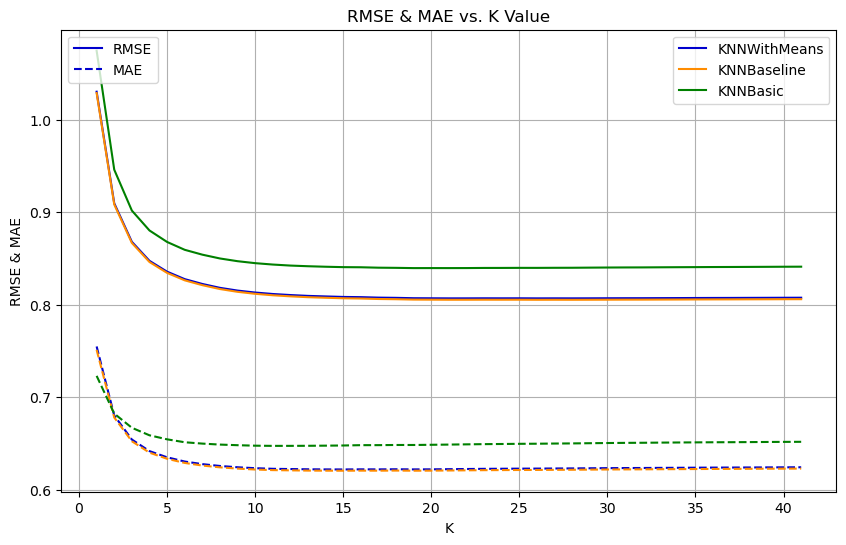

In [185]:
import matplotlib.pyplot as plt

color_wmean = 'mediumblue'
color_bline = 'darkorange'
color_basic = 'green'
maelinestyle = 'dashed'
xrange = range(1, 42)

plt.figure(figsize=(10,6))
ln1, = plt.plot(xrange, rmse_withmeans, color=color_wmean)
ln2, = plt.plot(xrange, rmse_baseline, color=color_bline)
ln3, = plt.plot(xrange, rmse_basic, color=color_basic)

ln4, = plt.plot(xrange, mae_withmeans, color=color_wmean, linestyle=maelinestyle)
plt.plot(xrange, mae_baseline, color=color_bline, linestyle=maelinestyle)
plt.plot(xrange, mae_basic, color=color_basic, linestyle=maelinestyle)

plt.title('RMSE & MAE vs. K Value')
plt.xlabel('K')
plt.ylabel('RMSE & MAE')

min_rmse = np.min(rmse_baseline)
print("Minimum RMSE: {:0.4f}".format(min_rmse))
min_mae = np.min(mae_baseline)
print("Minimum MAE: {:0.4f}".format(min_mae))

legend1 = plt.legend([ln1, ln4], ["RMSE", "MAE"], loc=2)
plt.legend([ln1, ln2, ln3], ["KNNWithMeans", "KNNBaseline", "KNNBasic"], loc=1)
plt.gca().add_artist(legend1)
plt.grid()
plt.show()

In [186]:
set_userID = set([i[0] for i in train_raw_ratings])
def generate_recommendationsKNN(similarity_matrix, userID=13552, like_recommend=40, get_recommend =10):
    if (userID not in set_userID) or type(userID) is not int:
        print("User id should be a valid integer from this list : \n\n {}".format(sorted(set_userID)))
        return []
    
    ''' This function generates "get_recommend" number of book recommendations using 
        KNNWithMeans & item based filtering. The function needs as input three 
        different parameters:
        (1) userID i.e., userID for which recommendations need to be generated 
        (2) like_recommend i.e., number of top recommendations for the userID to be 
        considered for making recommendations 
        (3) get_recommend i.e., number of recommendations to generate for the userID
        Default values are: userID=13552, like_recommend=5, get_recommend=10
    '''
    
    userID      = trainset.to_inner_uid(userID)    # converts the raw userID to innerID
    userRatings = trainset.ur[userID]              # method .ur takes user innerID & 
                                                   # returns back user ratings
    
    
    # userRatings is a list of tuples [(,),(,),(,)..]. Each tuple contains item & rating
    # given by the user for that item. Next, the tuples will be sorted within the list 
    # in decreasing order of rating. Then top 'like_recommend' items & ratings are extracted
    
    temp_df = pd.DataFrame(userRatings).sort_values(by=1, ascending=False).\
              head(like_recommend)
    userRatings = temp_df.to_records(index=False) 
    
    # for each (item,rating) in top like_recommend user items, multiply the user rating for
    # the item with the similarity score (later is obtained from item similarity_matrix) for
    # all items. This helps calculate the weighted rating for all items. The weighted ratings 
    # are added & divided by sum of weights to estimate rating the user would give an item
    
    recommendations   = {}

    for user_top_item, user_top_item_rating  in userRatings:

        all_item_indices          =   list(pd.DataFrame(similarity_matrix)[user_top_item].index)
        all_item_weighted_rating  =   list(pd.DataFrame(similarity_matrix)[user_top_item].values*\
                                          user_top_item_rating)
        
        all_item_weights          =   list(pd.DataFrame(similarity_matrix)[user_top_item].values)
        
        
        # All items & final estimated ratings are added to a dictionary called recommendations
        
        for index in range(len(all_item_indices)):
            if index in recommendations:
                # sum of weighted ratings
                recommendations[index] += all_item_weighted_rating[index]        
            else:                        
                recommendations[index]  = all_item_weighted_rating[index]

    
    for index in range(len(all_item_indices)):                               
            if all_item_weights[index]  !=0:
                # final ratings (sum of weighted ratings/sum of weights)
                recommendations[index]   =recommendations[index]/\
                                          (all_item_weights[index]*like_recommend)
                      

    # convert dictionary recommendations to a be a list of tuples [(,),(,),(,)]
    # with each tuple being an item & estimated rating user would give that item
    # SORT the tuples within the list to be in decreasing order of estimated ratings

    temp_df = pd.Series(recommendations).reset_index().sort_values(by=0, ascending=False)
    recommendations = list(temp_df.to_records(index=False))
    
    # return get_recommend number of recommedations (only return items the user 
    # has not previously rated)
    
    final_recommendations = []
    count = 0
    
    for item, score in recommendations:
        flag = True
        for userItem, userRating in trainset.ur[userID]:
            if item == userItem: 
                flag = False       # If item in recommendations has not been rated by user, 
                break              # add to final_recommendations
        if flag == True:
            final_recommendations.append(trainset.to_raw_iid(item)) 
            count +=1              # trainset has the items stored as inner id,  
                                   # convert to raw id & append 
            
        if count > get_recommend:  # Only get 'get_recommend' number of recommendations
            break
    
    return(final_recommendations)

In [187]:
def printRecommendations(similarity_matrix, user_id, k, get_top):
    recommendationsKNN = generate_recommendationsKNN(similarity_matrix, userID=user_id, like_recommend=k, get_recommend=get_top)

    print("\nRecommended Books for user {0} (item-based):".format(user_id))
    red = pd.DataFrame(recommendationsKNN,columns = ['isbn13'])
    red_ = red.merge(book.to_pandas(), on="isbn13")[['isbn13','title']]
    return red_

In [198]:
# Set the user and other values
base_user_id = 35227
base_k = 40
base_recommend = 20

In [199]:
# Compute item based similarity matrix
# KNNBaseline
best_baseline_sim_options['user_based'] = False
similarities_baseline = KNNBaseline(sim_options = best_baseline_sim_options).fit(trainset).\
                    compute_similarities() 

printRecommendations(similarities_baseline, base_user_id, base_k, base_recommend)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.

Recommended Books for user 35227 (item-based):


,isbn13,title
0,9780765388988,The Consuming Fire
1,9781417646401,East of Eden
2,9780751565355,Harry Potter and the Cursed Child: Parts One a...
3,9780062878021,Serpent & Dove
4,9781250866462,"Friends, Lovers, and the Big Terrible Thing"
5,9780452297548,Attachments
6,9780646418438,The Mysterious Affair at Styles
7,9781501144325,Why We Sleep: Unlocking the Power of Sleep and...
8,9780349431239,"Take a Hint, Dani Brown"
9,9780143122357,The Haunting of Hill House


In [200]:
# Compute item based similarity matrix
# KNNBasic
similarities_basic = KNNBasic(sim_options = best_basic_sim_options).fit(trainset).\
                    compute_similarities() 

printRecommendations(similarities_basic, base_user_id, base_k, base_recommend)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.

Recommended Books for user 35227 (item-based):


,isbn13,title
0,9780765388988,The Consuming Fire
1,9781417646401,East of Eden
2,9780751565355,Harry Potter and the Cursed Child: Parts One a...
3,9780062878021,Serpent & Dove
4,9781250866462,"Friends, Lovers, and the Big Terrible Thing"
5,9780452297548,Attachments
6,9780646418438,The Mysterious Affair at Styles
7,9781501144325,Why We Sleep: Unlocking the Power of Sleep and...
8,9780349431239,"Take a Hint, Dani Brown"
9,9780143122357,The Haunting of Hill House


In [201]:
# Compute item based similarity matrix
# KNNWithMeans
similarities_mean = KNNWithMeans(sim_options = best_withmeans_sim_options).fit(trainset).\
                    compute_similarities()

printRecommendations(similarities_mean, base_user_id, base_k, base_recommend)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.

Recommended Books for user 35227 (item-based):


,isbn13,title
0,9780765388988,The Consuming Fire
1,9781417646401,East of Eden
2,9780751565355,Harry Potter and the Cursed Child: Parts One a...
3,9780062878021,Serpent & Dove
4,9781250866462,"Friends, Lovers, and the Big Terrible Thing"
5,9780452297548,Attachments
6,9780646418438,The Mysterious Affair at Styles
7,9781501144325,Why We Sleep: Unlocking the Power of Sleep and...
8,9780349431239,"Take a Hint, Dani Brown"
9,9780143122357,The Haunting of Hill House


In [192]:
rating_books.filter(pl.col("count") > 50).sort("count")

userid,count
i64,u32
33036,51
35227,51
31941,51
37714,51
32951,51
…,…
33149,2303
18060,2672
2386,3309


In [205]:
rating_all.filter(pl.col("userid") == base_user_id).sort('title')

userid,isbn13,rating_score,title
i64,str,f64,str
35227,"""9780385007511""",5.0,"""'Salem's Lot"""
35227,"""9780330319928""",4.5,"""American Psycho"""
35227,"""9780007282319""",5.0,"""And Then There Were None"""
35227,"""9781443428392""",4.5,"""Annihilation"""
35227,"""9780340921357""",4.0,"""Bag of Bones"""
…,…,…,…
35227,"""9780045113965""",5.0,"""The Shining"""
35227,"""9780307595867""",4.5,"""The Snowman"""
35227,"""9780593314012""",5.0,"""The Stand"""
